# 4 - Chord Analysis

## Imports + Functions

In [10]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import music21 as m21

import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import General as g
from Importables import intervalanalysis_utils as ia

In [14]:
def group_chords(label):
    try:
        chord = m21.harmony.ChordSymbol(label)
        quality = chord.quality
        root = chord.root()
        chord_group = root.name + ' ' + quality
    except:
        chord_group = np.nan
    return chord_group

In [16]:
def group_chords_exception(labels):
    exceptions = []
    for _, row in labels.iterrows():
        label = row['label']
        try:
            chord = m21.harmony.ChordSymbol(label)
            quality = chord.quality
            if quality == 'other':
                exceptions.append(label)
        except:
            exceptions.append(label)

    return pd.Series(exceptions).value_counts()
        

## Load Data

In [19]:
metadata = g.load_metadata()
labels = g.load_labels(metadata)

## Chord Group Frequencies

In [22]:
labels['chord_group'] = labels['label'].apply(group_chords)

In [24]:
exceptions = group_chords_exception(labels)
exceptions

Cm69          134
A7sus4         31
E-69           30
E13no3         27
F13no3         27
             ... 
E69             1
G7b9#9b5#5      1
F69             1
D7b9#9b5#5      1
Dsus4           1
Length: 89, dtype: int64

In [26]:
labels_grouped = labels.value_counts(subset='chord_group')
labels_grouped

chord_group
B- major        2630
F major         2621
G major         2280
C major         2185
E- major        2006
                ... 
G# augmented       2
E- augmented       1
D# other           1
B# major           1
A# minor           1
Length: 79, dtype: int64

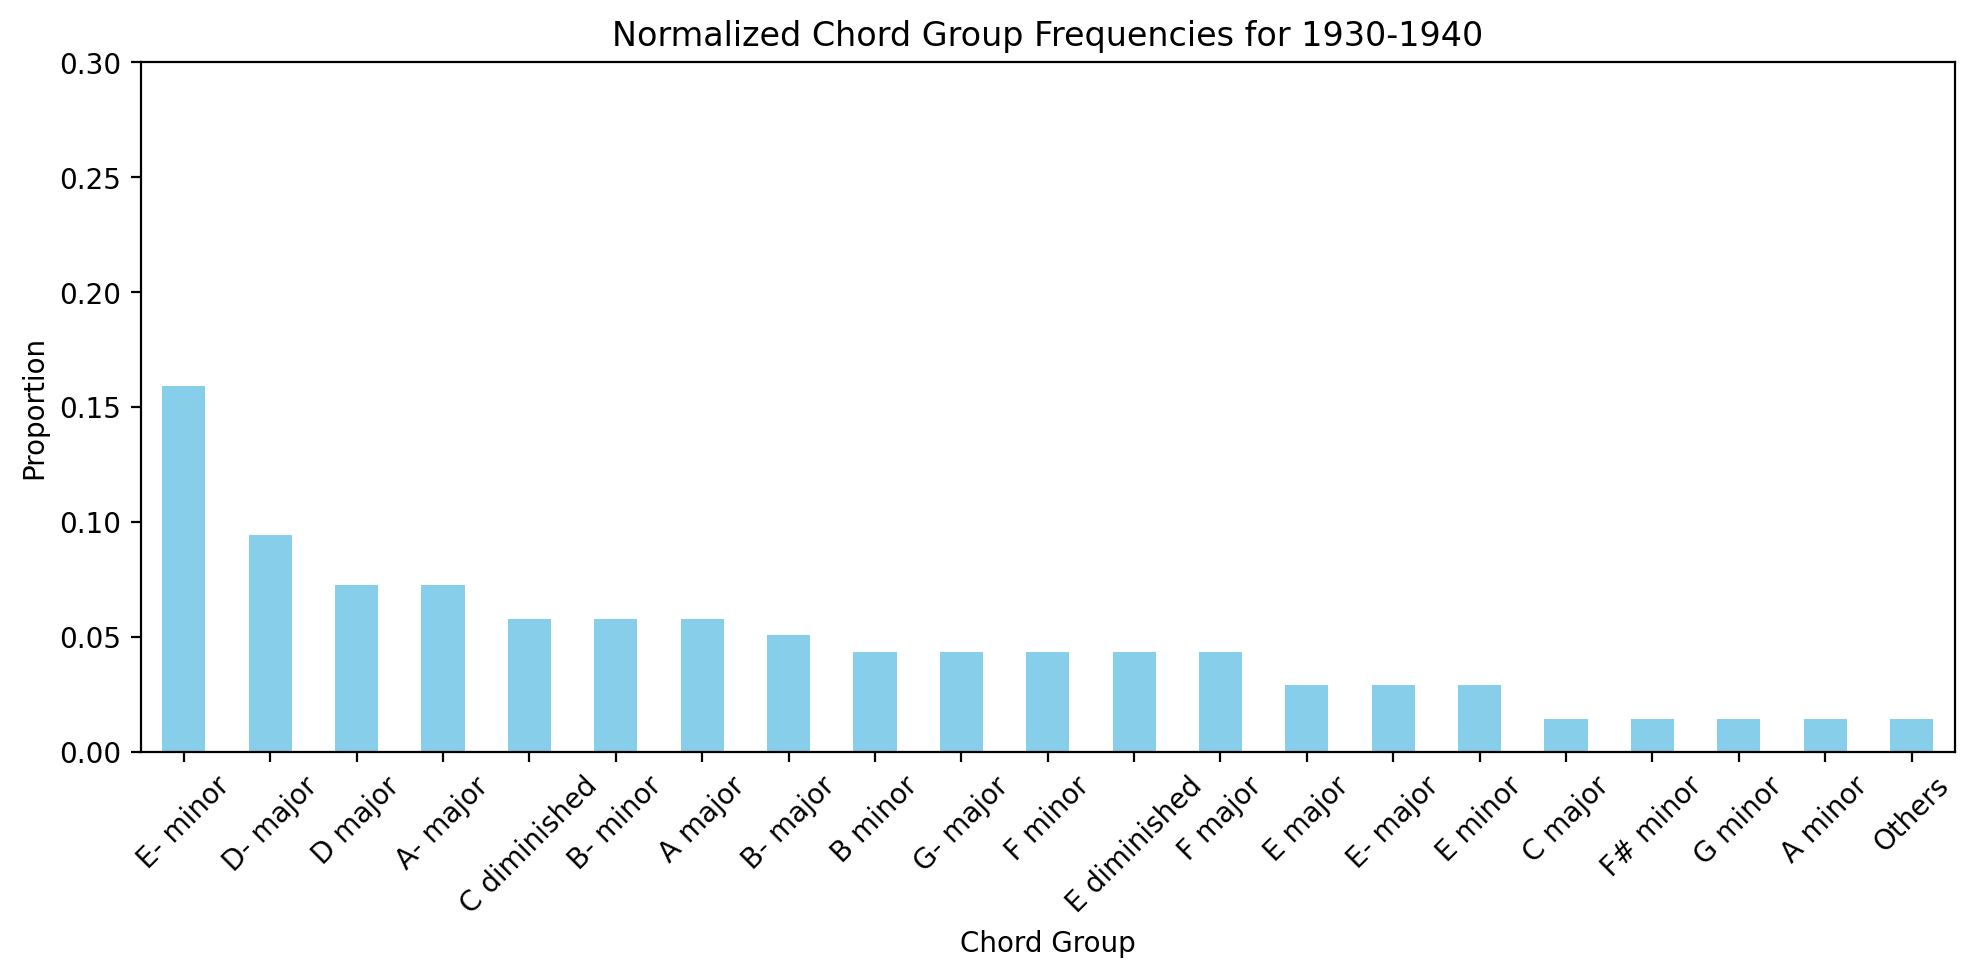

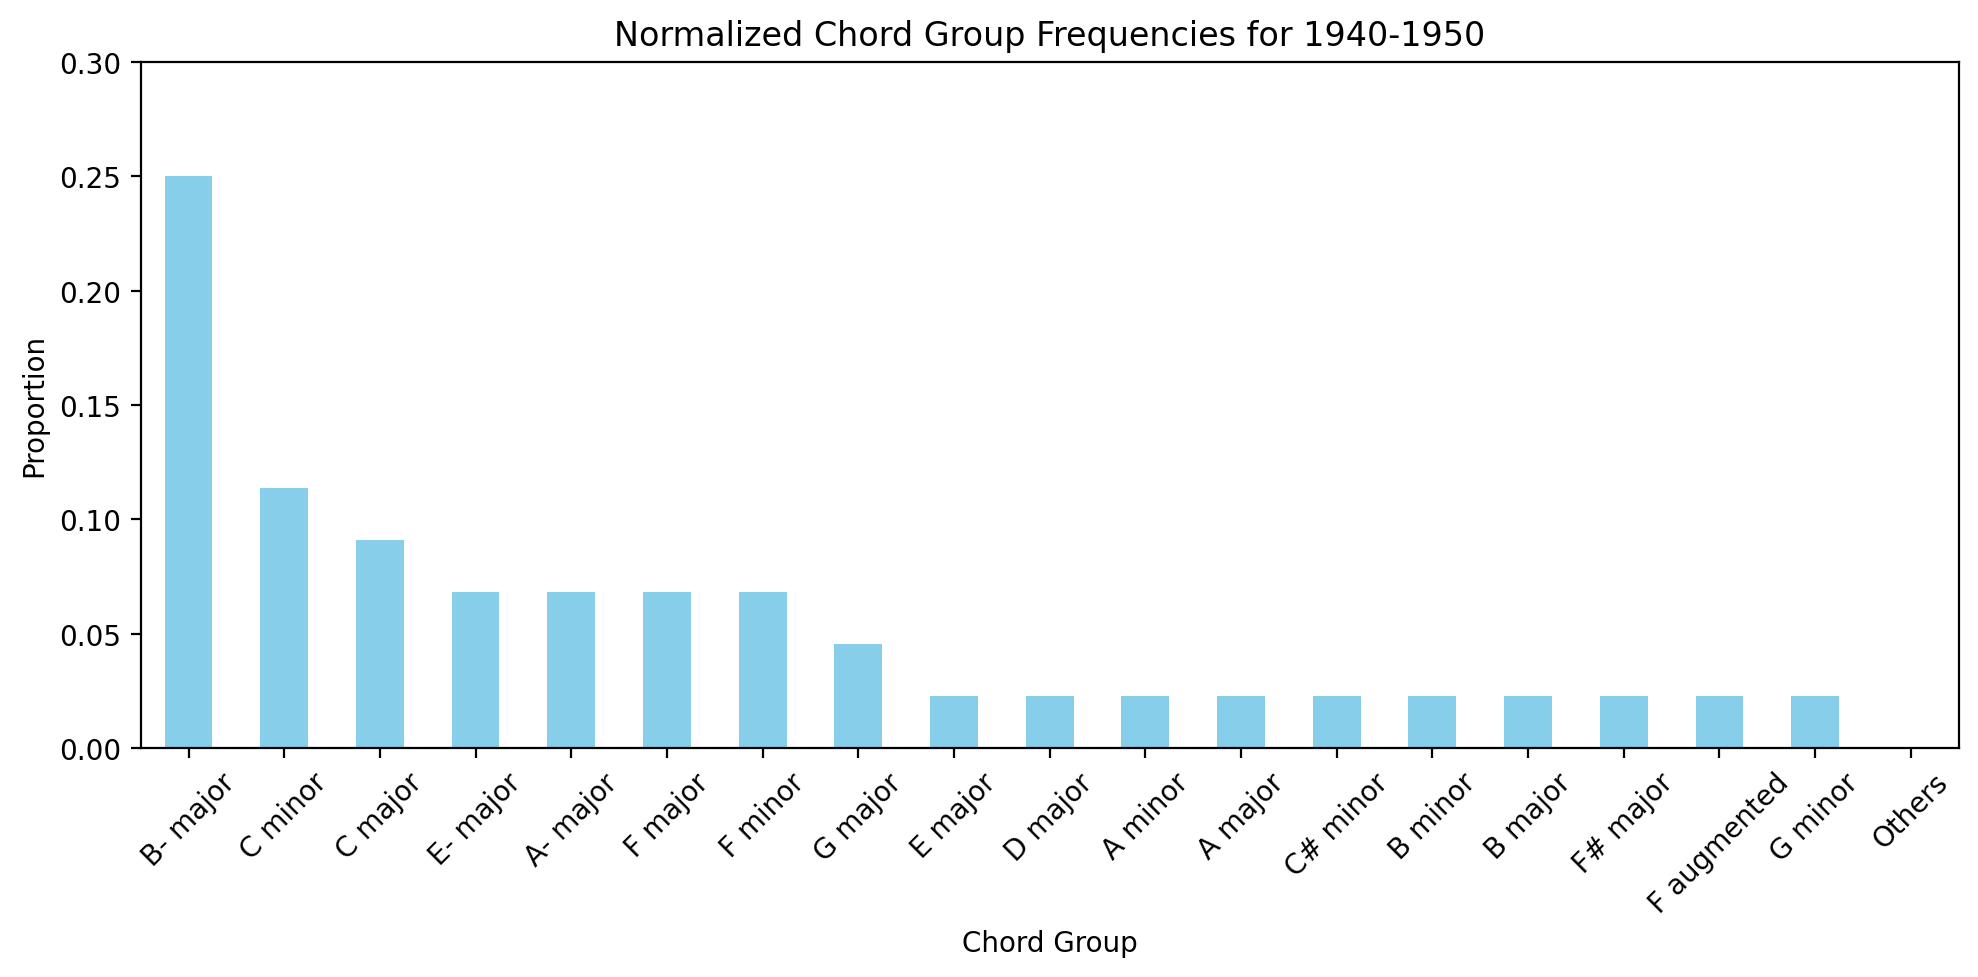

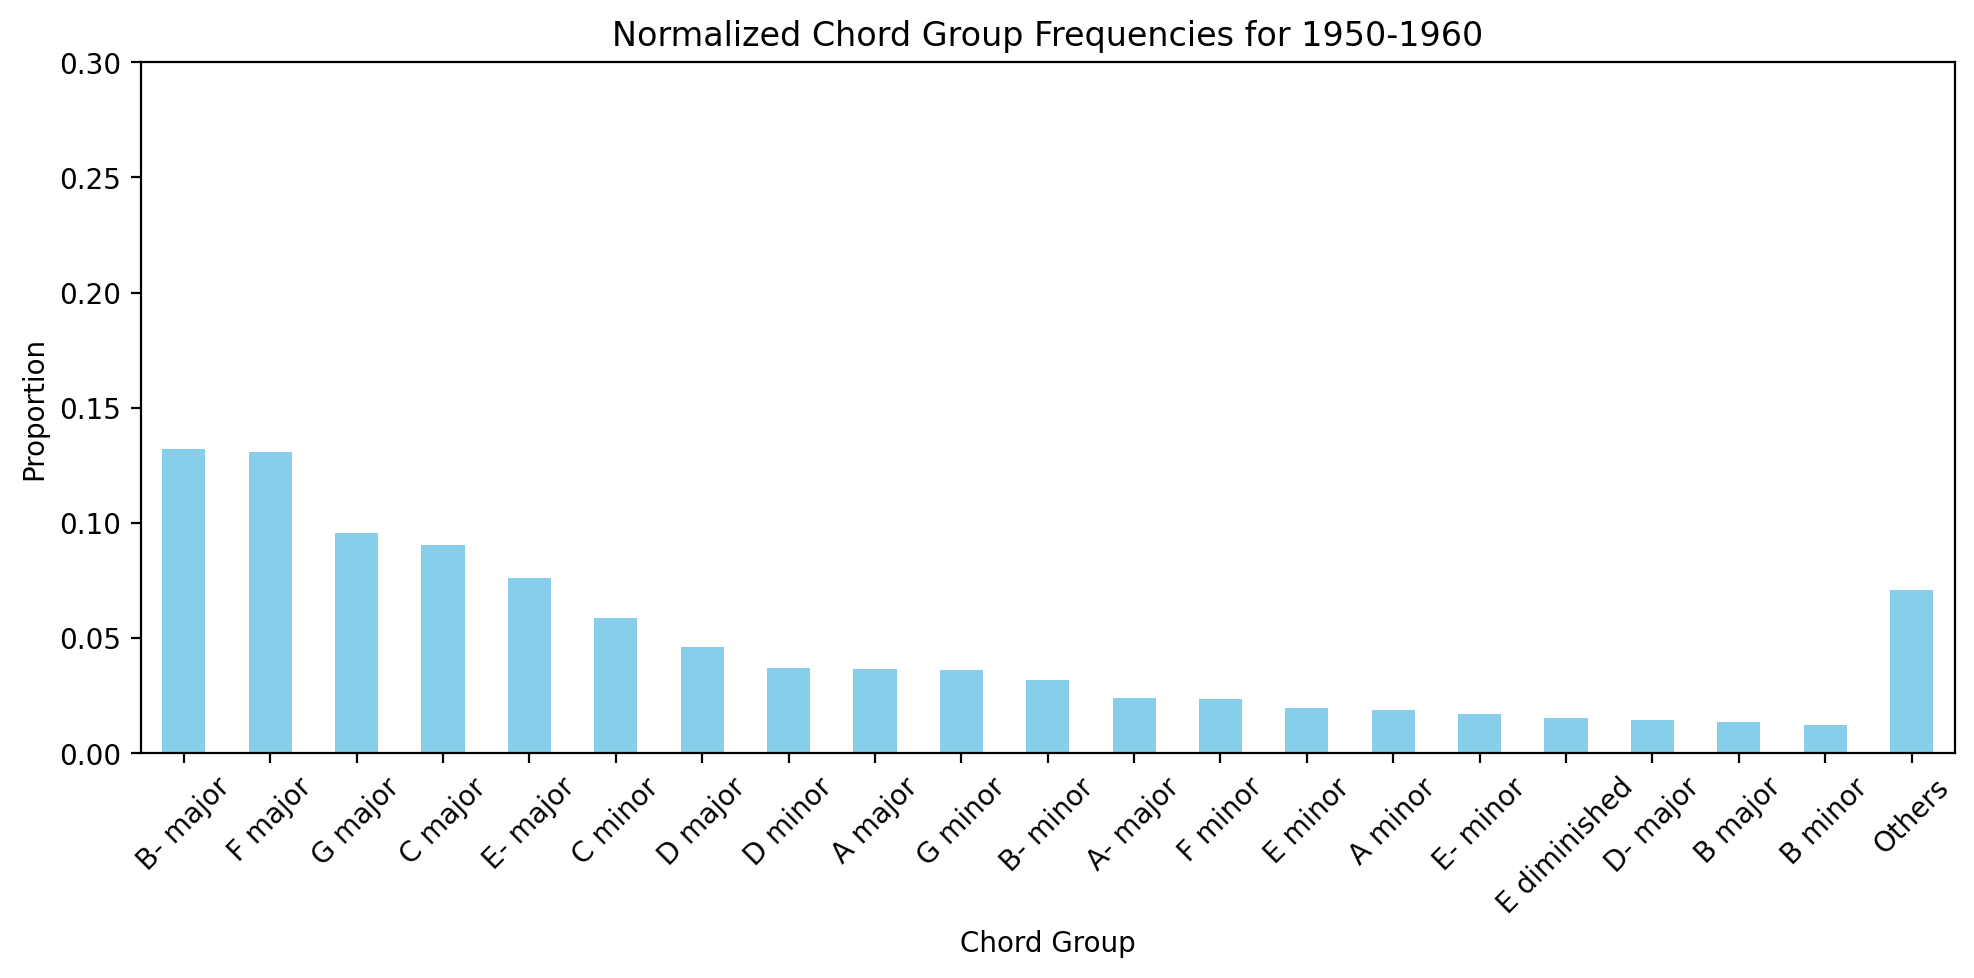

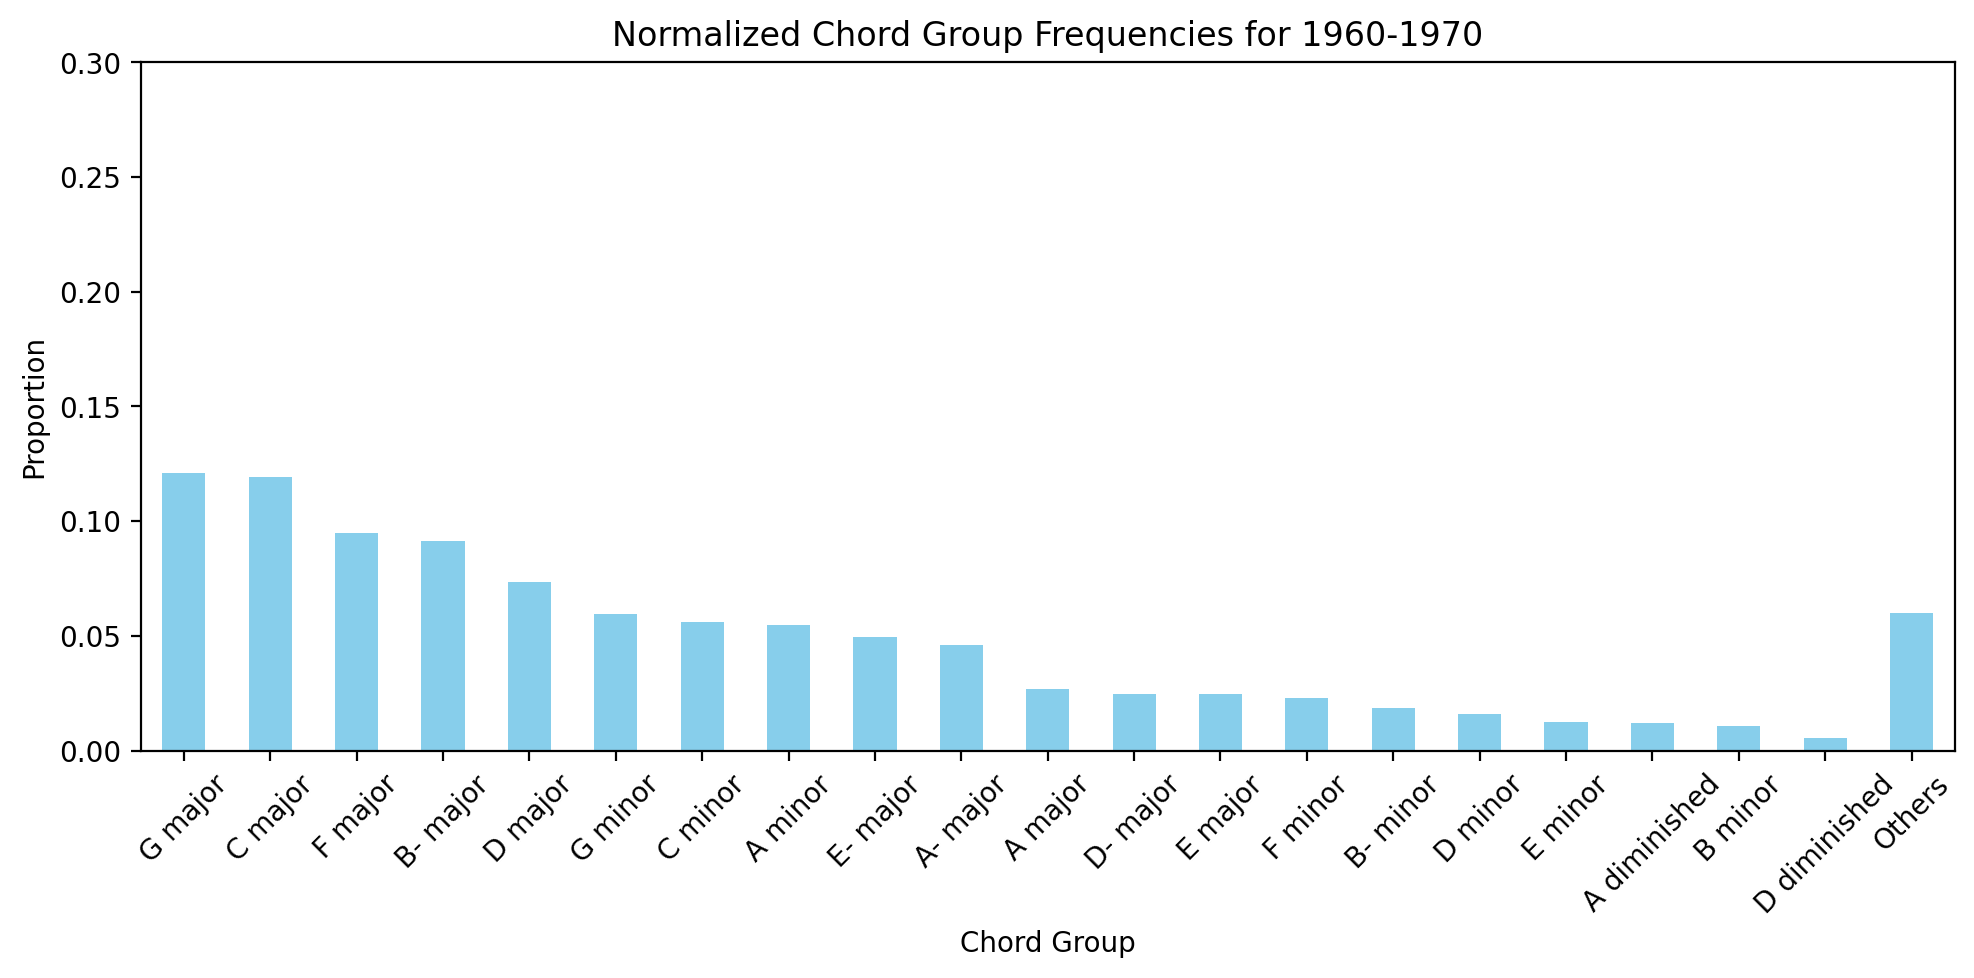

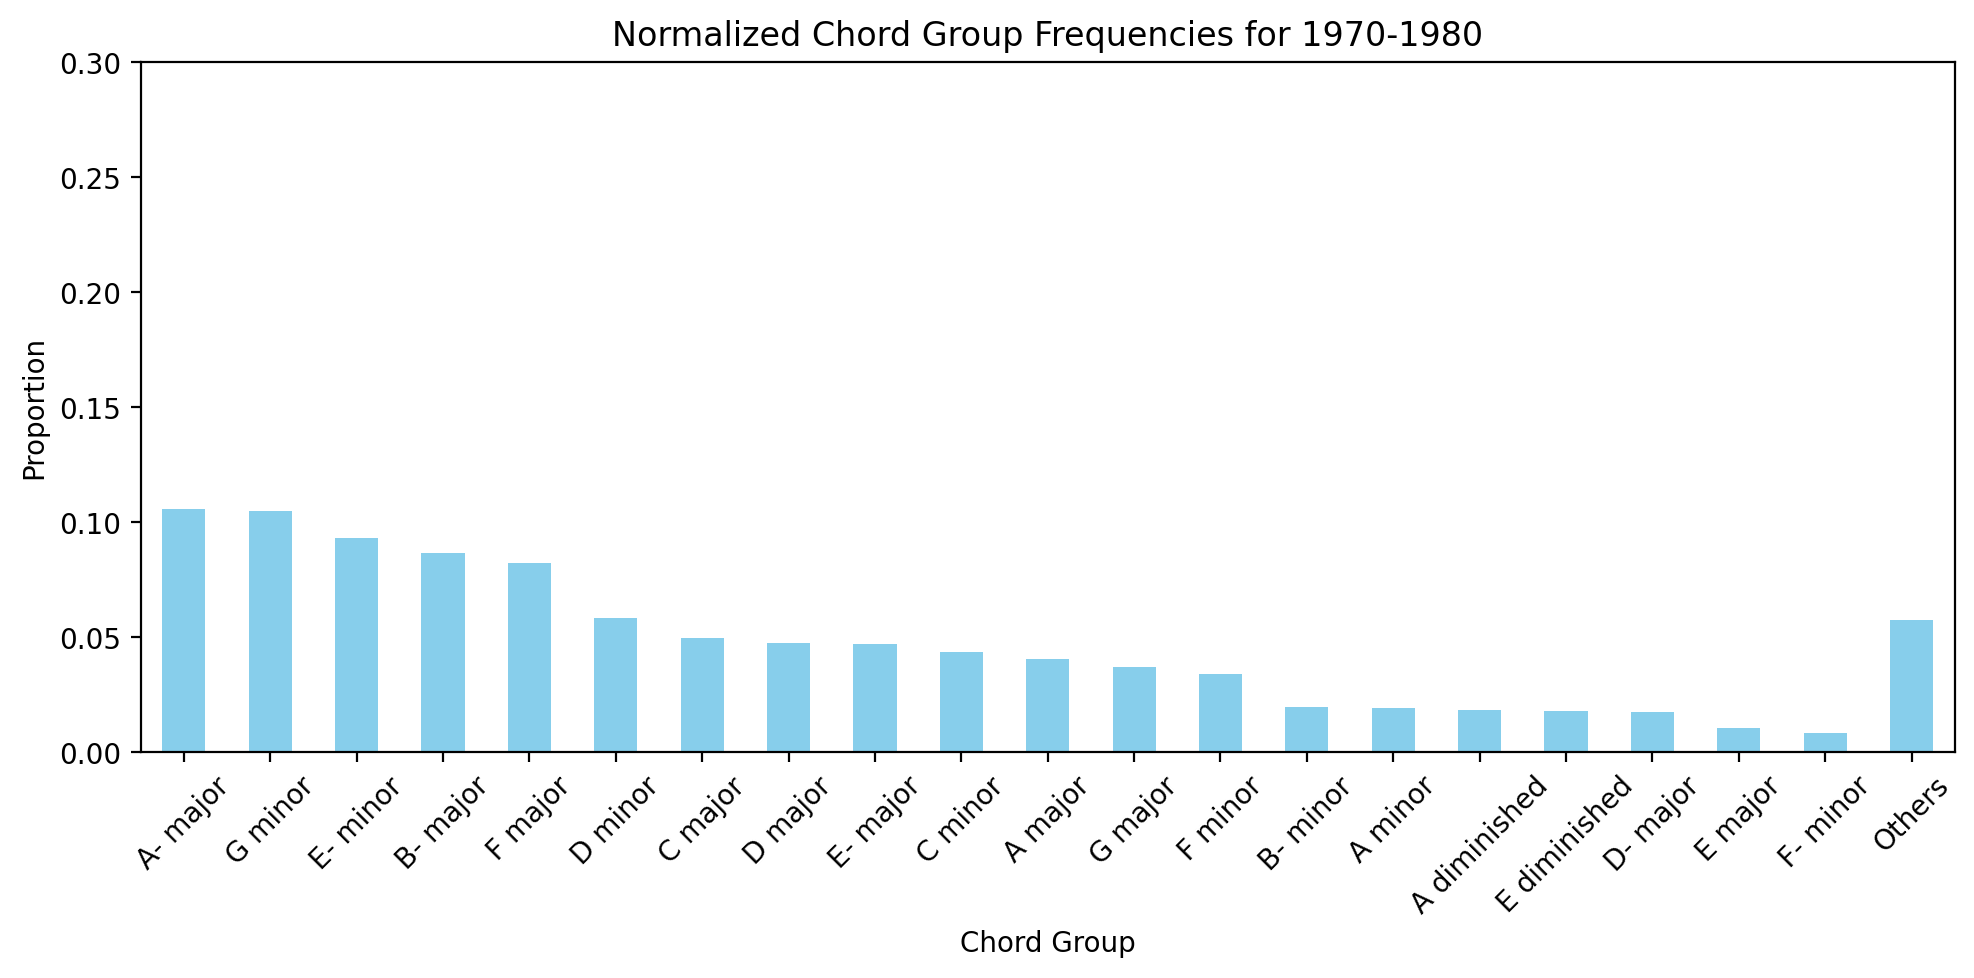

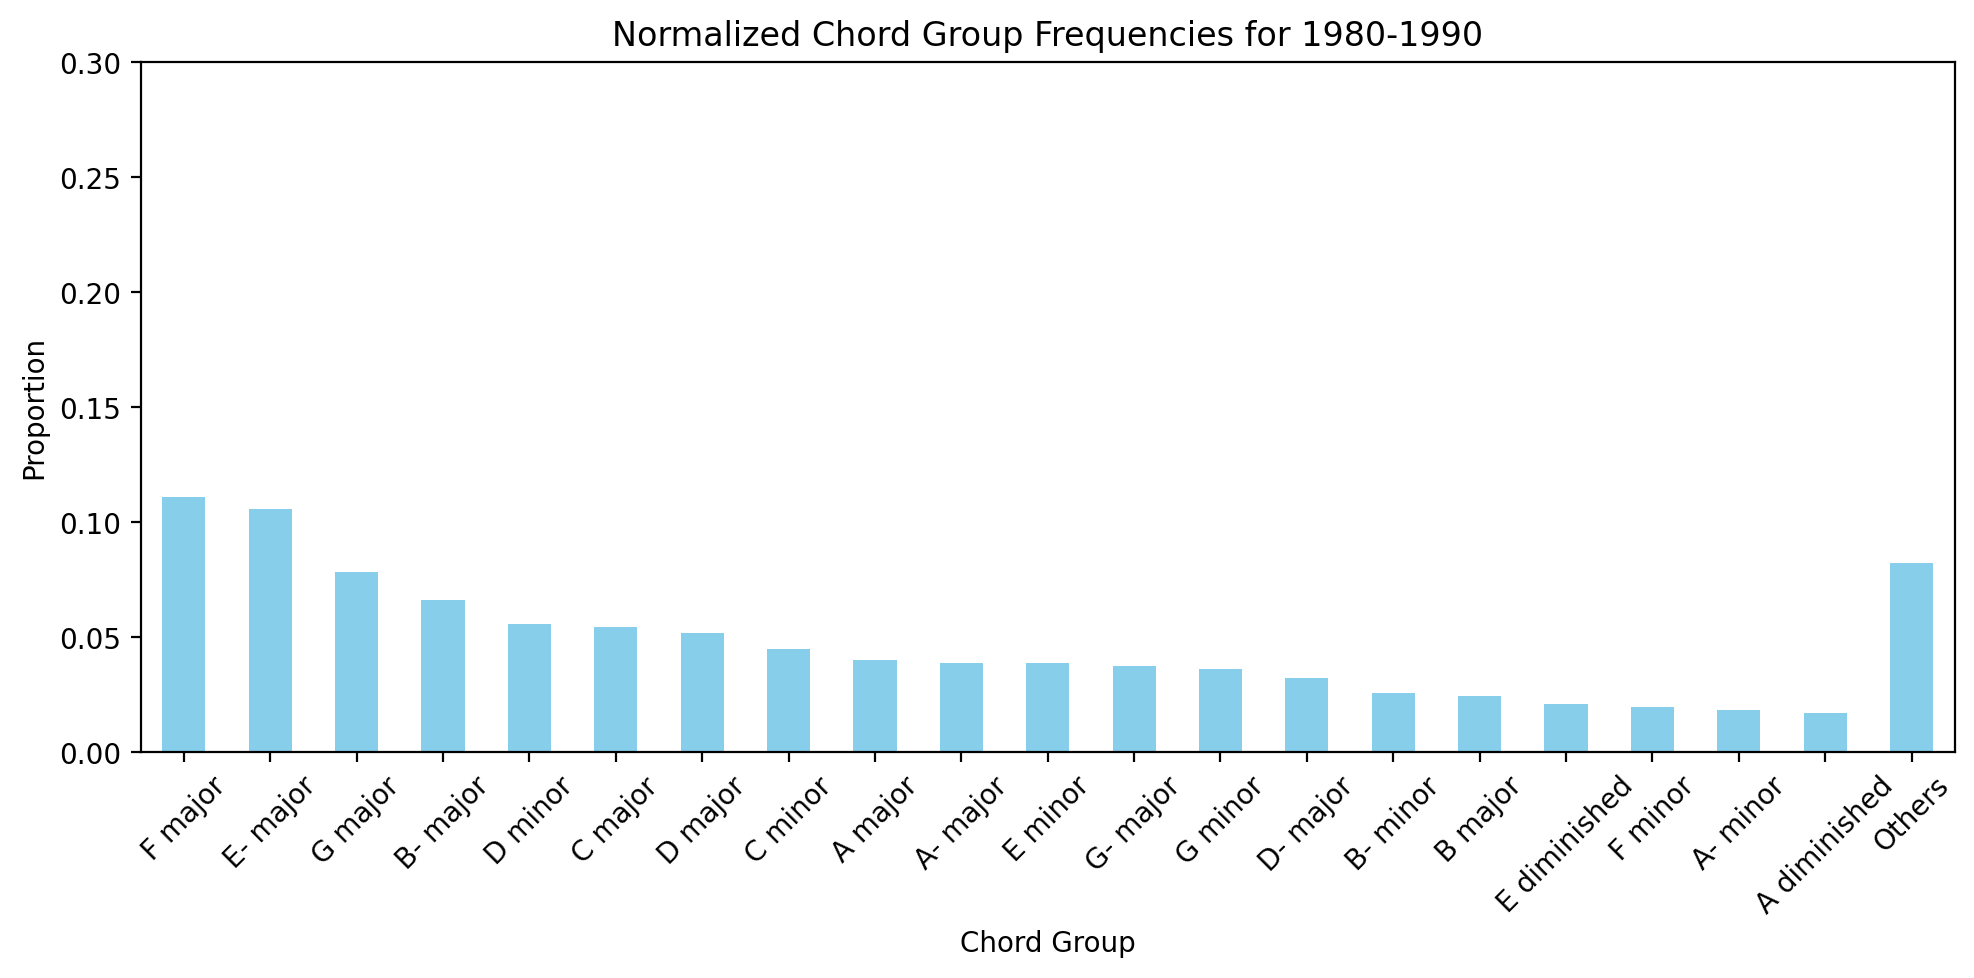

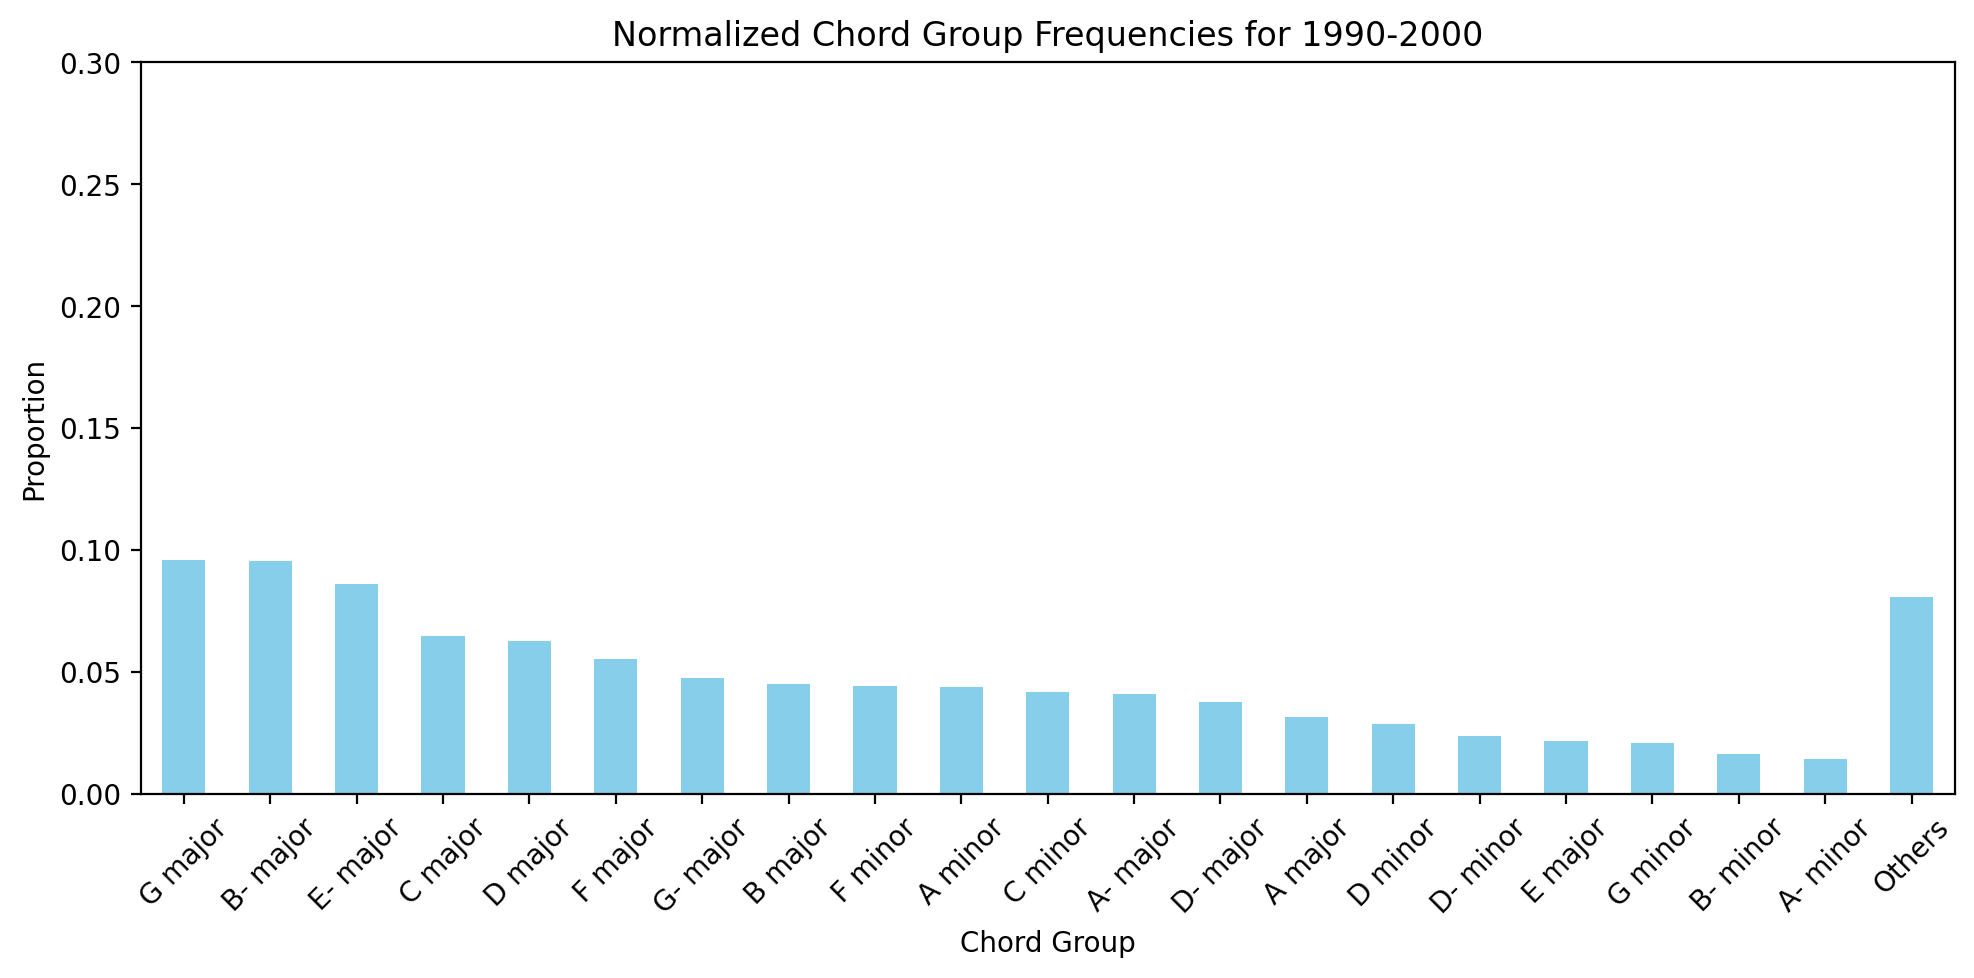

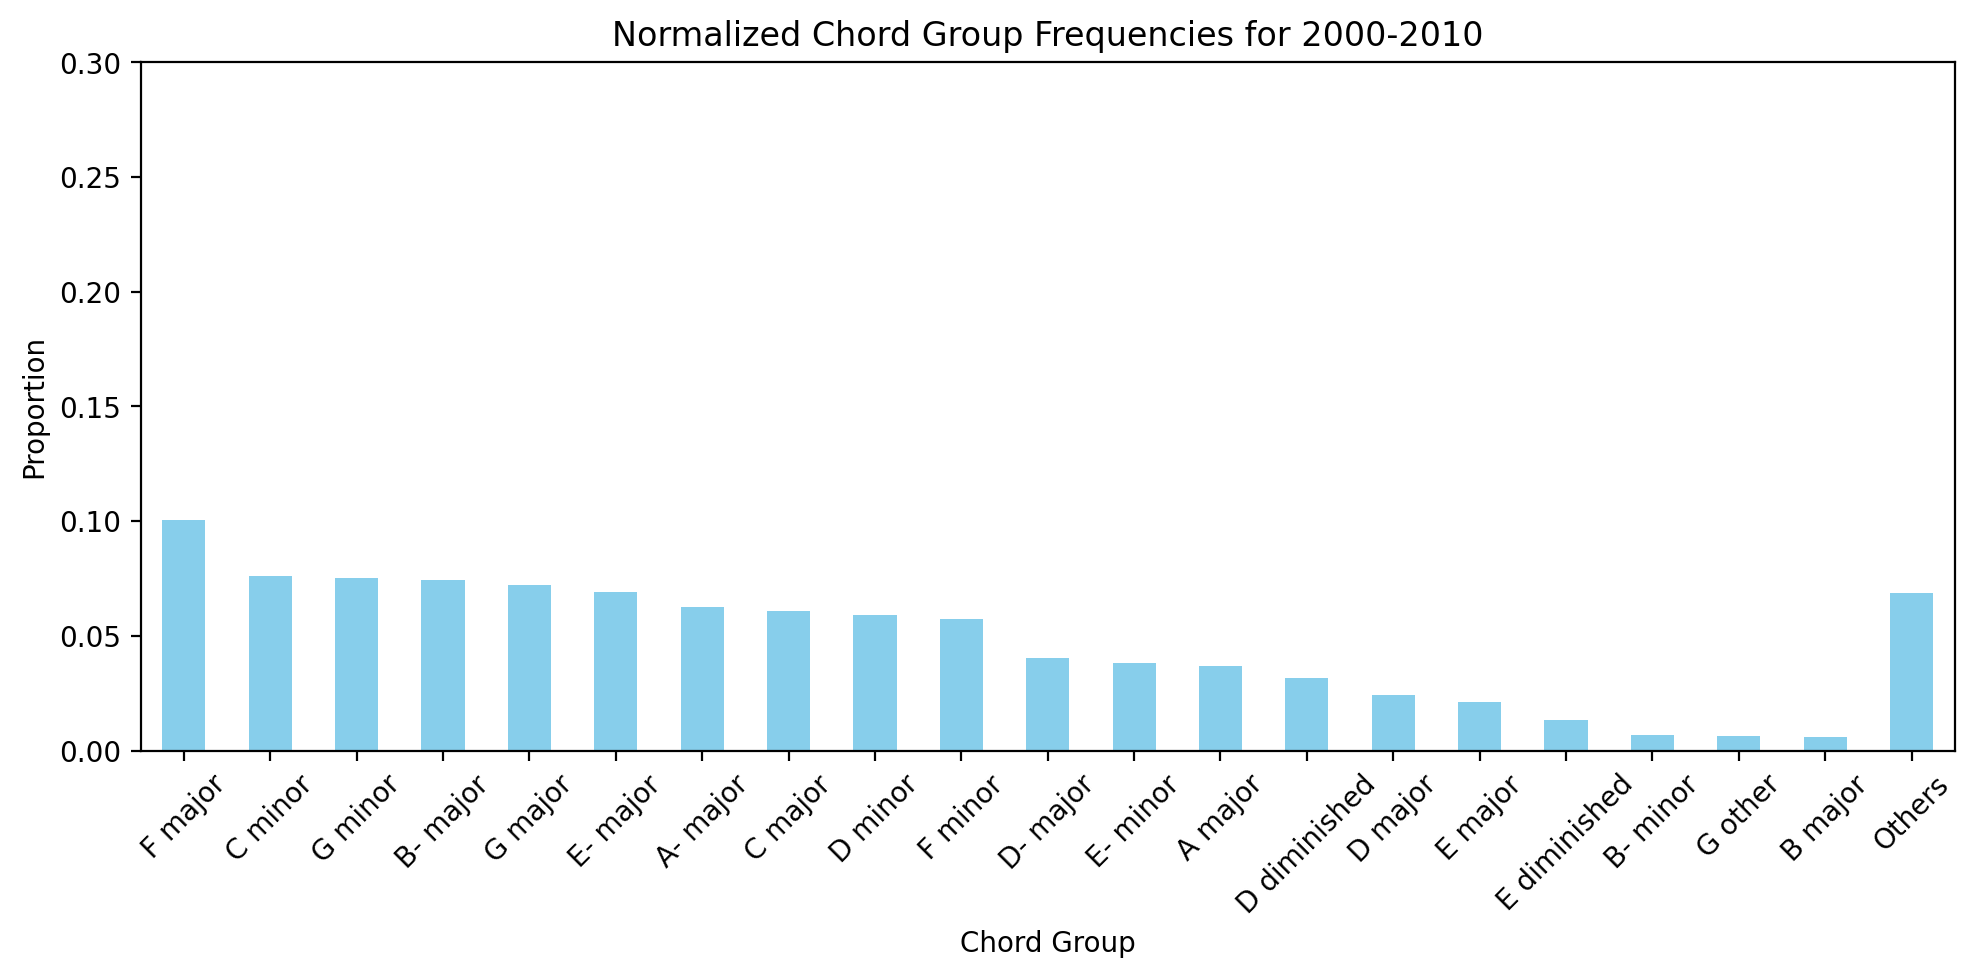

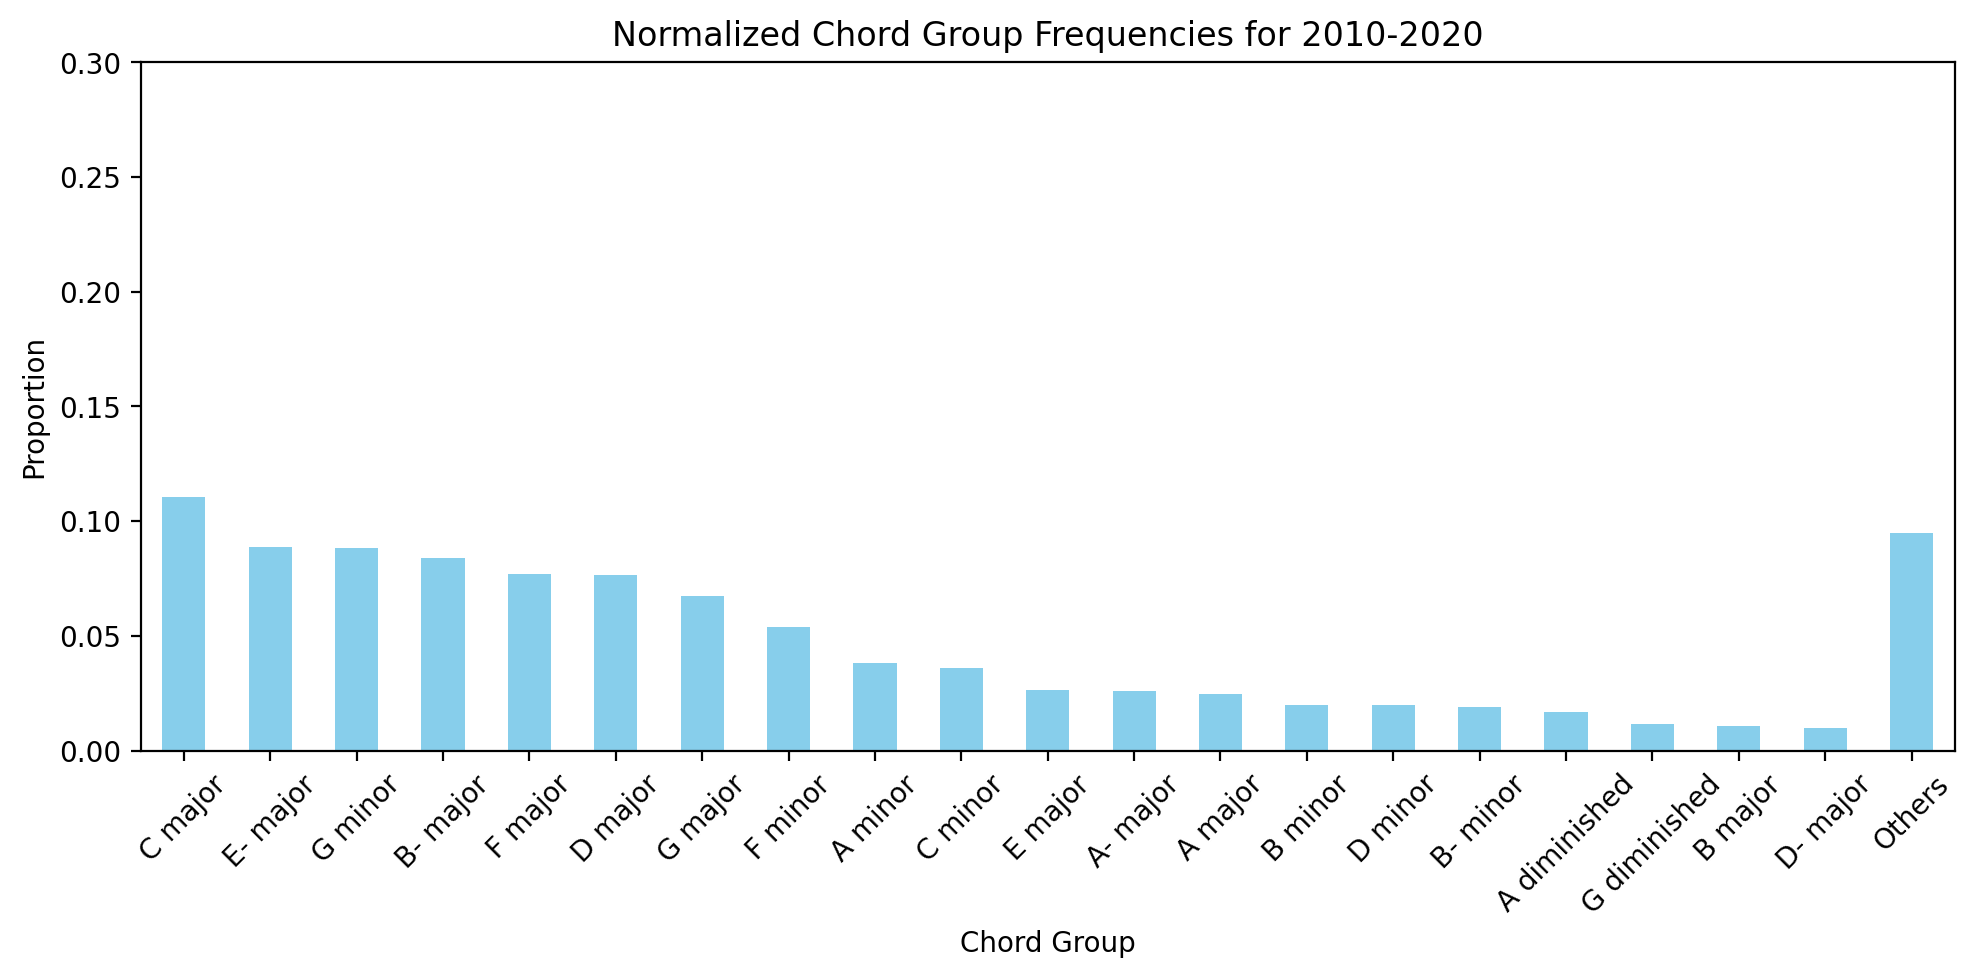

In [28]:
for year_bin in g.bin_labels:
    bin_data = labels[labels['year_bin'] == year_bin]

    freq = bin_data['chord_group'].value_counts(normalize=True)
    
    top = freq.head(20)

    others_sum = freq.iloc[20:].sum()

    top['Others'] = others_sum

    # Plot
    plt.figure(figsize=(10, 5))
    top.plot(kind='bar', color='skyblue')
    plt.title(f'Normalized Chord Group Frequencies for {year_bin}')
    plt.xlabel('Chord Group')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45)
    plt.ylim(0, 0.3)
    plt.tight_layout()
    plt.show()
    

### Chord Group Pitch Composition

In [31]:
notes = g.load_notes(metadata)

In [32]:
notes['chord_group'] = notes['label'].apply(group_chords)

In [33]:
top_list = labels_grouped.head(10).index.tolist()
notes_subset = notes[notes['chord_group'].isin(top_list)]

In [34]:
notes_subset

,mc,mn,mc_onset,mn_onset,timesig,staff,voice,duration,gracenote,nominal_duration,...,time,artist,workTitle,fnames,rel_paths,recording_year,year_bin,label,ILS,chord_group
4648,46,46,0.000000,0,4/4,5,1,0.062500,NaN,1/16,...,46.000000,The Fearless Flyers,Ace Of Aces,The_Fearless_Flyers-Ace_of_Aces,by_Alexander_Booker,2018.0,2010-2020,G9,"[G, B, D, F, A]",G major
4649,46,46,0.000000,0,4/4,3,1,0.125000,NaN,1/8,...,46.000000,The Fearless Flyers,Ace Of Aces,The_Fearless_Flyers-Ace_of_Aces,by_Alexander_Booker,2018.0,2010-2020,G9,"[G, B, D, F, A]",G major
4650,46,46,0.000000,0,4/4,4,1,0.125000,NaN,1/8,...,46.000000,The Fearless Flyers,Ace Of Aces,The_Fearless_Flyers-Ace_of_Aces,by_Alexander_Booker,2018.0,2010-2020,G9,"[G, B, D, F, A]",G major
4651,46,46,0.000000,0,4/4,1,1,0.250000,NaN,1/4,...,46.000000,The Fearless Flyers,Ace Of Aces,The_Fearless_Flyers-Ace_of_Aces,by_Alexander_Booker,2018.0,2010-2020,G9,"[G, B, D, F, A]",G major
4652,46,46,0.062500,1/16,4/4,5,1,0.062500,NaN,1/16,...,46.062500,The Fearless Flyers,Ace Of Aces,The_Fearless_Flyers-Ace_of_Aces,by_Alexander_Booker,2018.0,2010-2020,G9,"[G, B, D, F, A]",G major
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188604,62,62,0.250000,1/4,4/4,1,1,0.250000,NaN,1/4,...,62.250000,Vincent Nilsson,Kids Are Pretty People,Kids Are Pretty People - Vincent Nilsson,by_seemajorsheetmusic,1978.0,1970-1980,B-7,"[B-, D, F, A-]",B- major
188605,62,62,0.562500,9/16,4/4,1,1,0.187500,NaN,1/8,...,62.562500,Vincent Nilsson,Kids Are Pretty People,Kids Are Pretty People - Vincent Nilsson,by_seemajorsheetmusic,1978.0,1970-1980,E-7,"[E-, G, B-, D-]",E- major
188606,62,62,0.833333,5/6,4/4,1,1,0.083333,NaN,1/8,...,62.833333,Vincent Nilsson,Kids Are Pretty People,Kids Are Pretty People - Vincent Nilsson,by_seemajorsheetmusic,1978.0,1970-1980,E-7,"[E-, G, B-, D-]",E- major
188607,62,62,0.916667,11/12,4/4,1,1,0.083333,NaN,1/8,...,62.916667,Vincent Nilsson,Kids Are Pretty People,Kids Are Pretty People - Vincent Nilsson,by_seemajorsheetmusic,1978.0,1970-1980,E-7,"[E-, G, B-, D-]",E- major


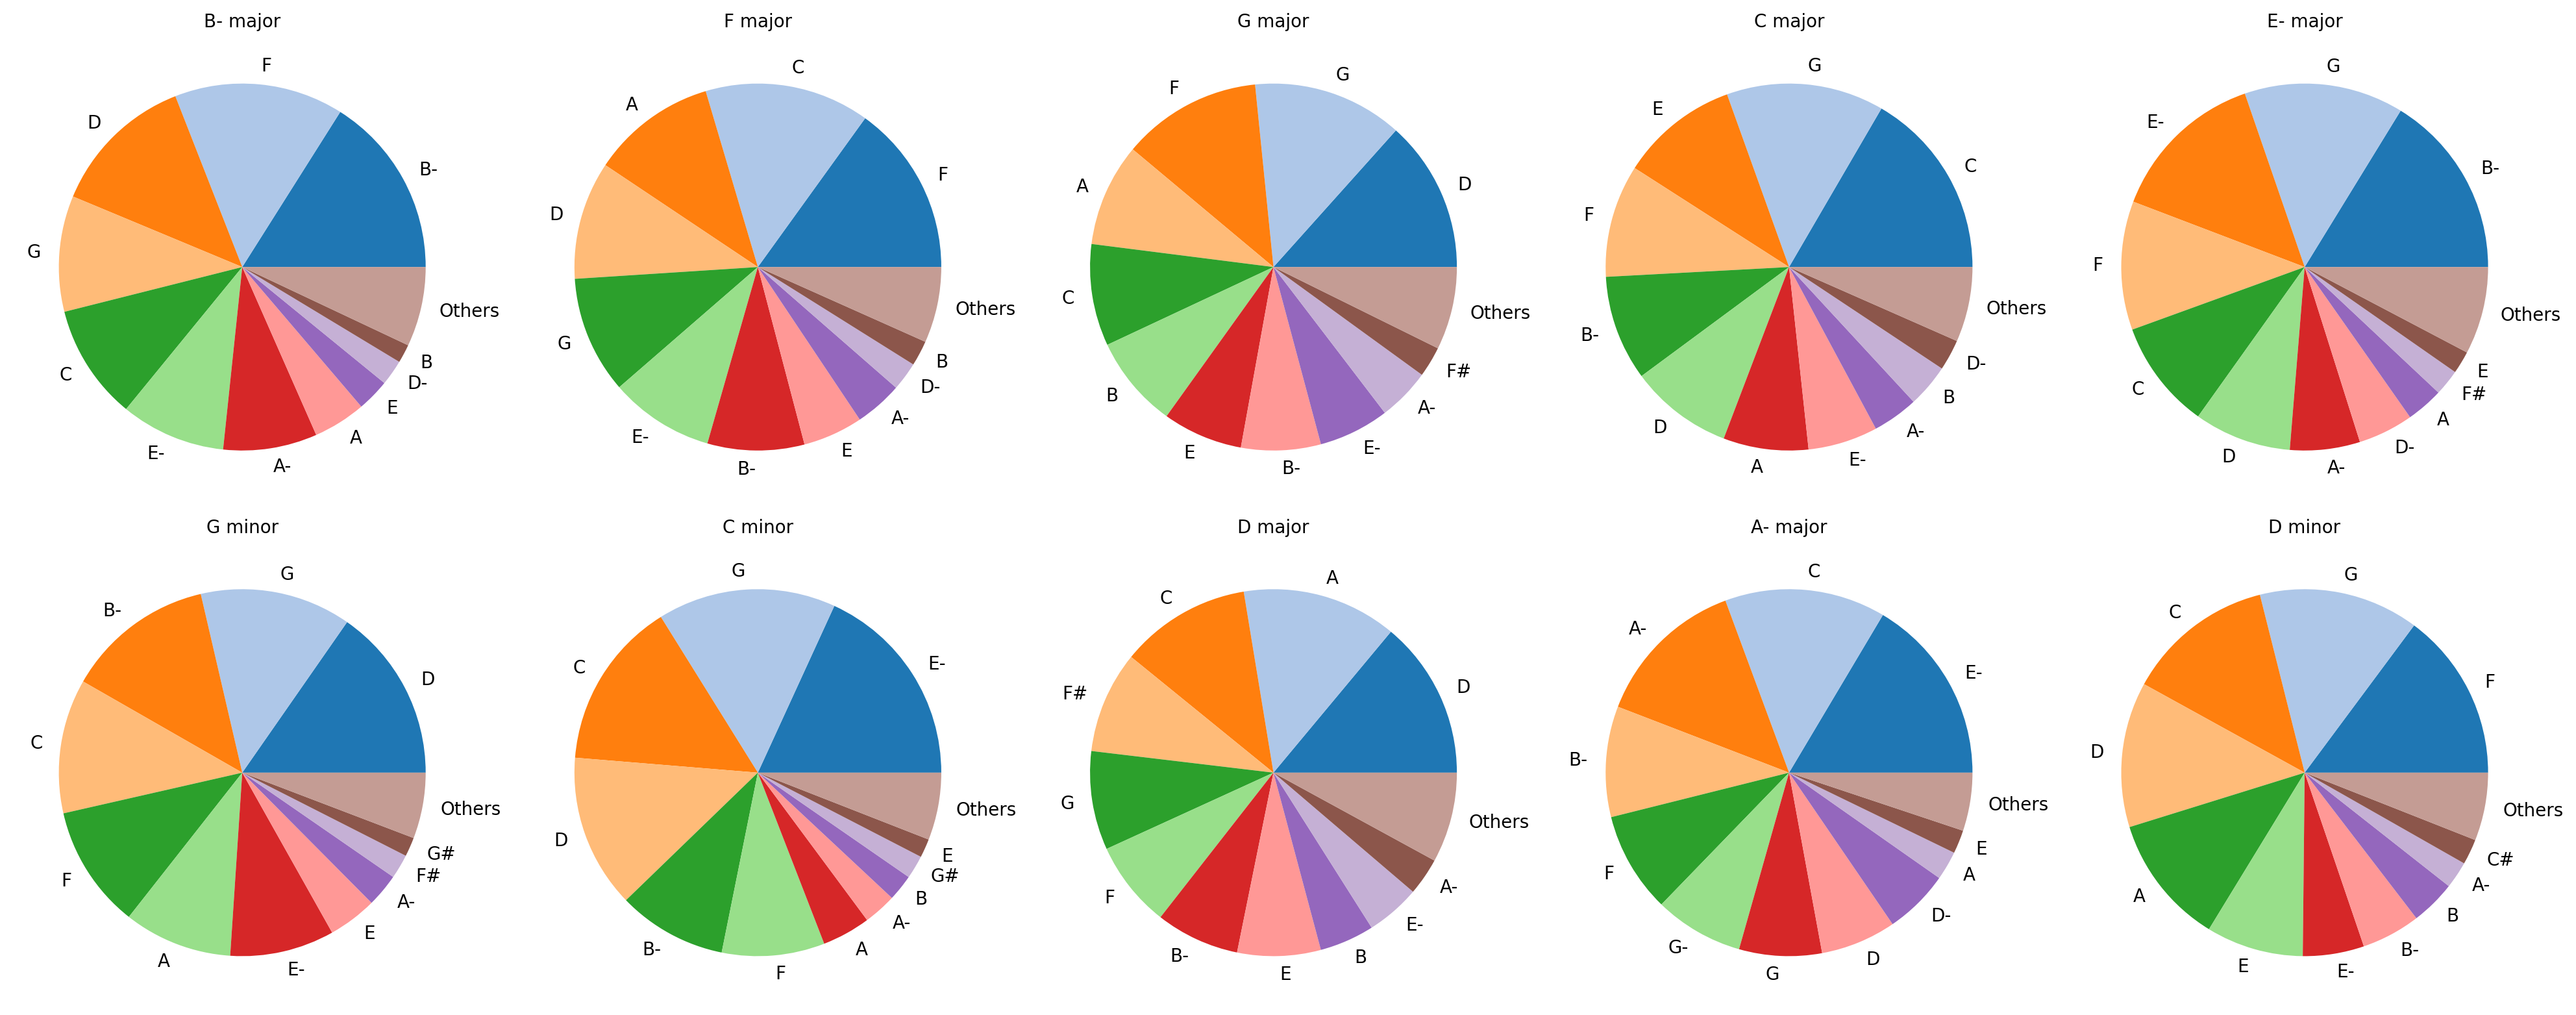

In [35]:
rows, cols = 2, 5

fig, axes = plt.subplots(rows, cols, figsize=(20, 8), subplot_kw=dict(aspect="equal"))
axes = axes.flatten() 

cmap = plt.get_cmap('tab20')

for i, label in enumerate(top_list):
    label_data = notes_subset[notes_subset['chord_group'] == label]
    freq = label_data['note'].value_counts()
    
    top_num = 11
    top = freq.head(top_num)
    others_sum = freq.iloc[top_num:].sum()
    top['Others'] = others_sum
    
    colours = cmap.colors[:len(top)]

    ax = axes[i]
    ax.pie(top, labels=top.index, colors=colours)
    ax.set_title(f'{label}', fontsize=10)

plt.tight_layout()
plt.show()